# Python Foundations Project: Austo



## Problem Statement

### Context

In the 21st century, cars are an important mode of transportation that provides us the opportunity for personal control and autonomy. In day-to-day life, people use cars for commuting to work, shopping, visiting family and friends, etc. Research shows that more than 76% of people prevent themselves from traveling somewhere if they don't have a car. Most people tend to buy different types of cars based on their day-to-day necessities and preferences. So, it is essential for automobile companies to analyze the preference of their customers before launching a car model into the market. Austo, a UK-based automobile company aspires to grow its business into the US market after successfully establishing its footprints in the European market.

In order to be familiar with the types of cars preferred by the customers and factors influencing the car purchase behavior in the US market, Austo has contracted a consulting firm. Based on various market surveys, the consulting firm has created a dataset of 3 major types of cars that are extensively used across the US market. They have collected various details of the car owners which can be analyzed to understand the automobile market of the US.

### Objective

Austo's management team wants to understand the demand of the buyers and trends in the US market. They want to build customer profiles based on the analysis to identify new purchase opportunities so that they can manipulate the business strategy and production to meet certain demand levels. Further, the analysis will be a good way for management to understand the dynamics of a new market. Suppose you are a Data Scientist working at the consulting firm that has been contracted by Austo. You are given the task to create buyer's profiles for different types of cars with the available data as well as a set of recommendations for Austo. Perform the data analysis to generate useful insights that will help the automobile company to grow its business.

### Data Description

austo_automobile.csv: The dataset contains buyer's data corresponding to different types of products(cars).

### Data Dictionary

* Age: Age of the customer
* Gender: Gender of the customer
* Profession: Indicates whether the customer is a salaried or business person
* Marital_status: Marital status of the customer
* Education: Refers to the highest level of education completed by the customer
* No_of_dependents: Number of dependents(partner/children/spouse) of the customer
* Personal_loan: Indicates whether the customer availed a personal loan or not
* House_loan: Indicates whether the customer availed house loan or not
* Partner_working: Indicates whether the customer's partner is working or not
* Salary: Annual Salary of the customer
* Partner_salary: Annual Salary of the customer's partner
* Total_salary: Annual household income (Salary + Partner_salary) of the customer's family
* Price: Price of the car
* Make: Car type (Hatchback/Sedan/SUV)

## Importing necessary libraries

In [0]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [0]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Importing the dataset

In [0]:
import os
file_path = os.path.abspath('Storage/austo_automobile.csv')
df = pd.read_csv(file_path, on_bad_lines='skip')

In [0]:
# return the first 5 rows
df.head()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,24,Male,Salaried,Married,Post Graduate,4,No,Yes,Yes,52000,25000,77000,18000,Hatchback
1,28,Male,Salaried,Married,Post Graduate,3,No,Yes,No,68000,0,68000,18000,Hatchback
2,23,Male,Salaried,Married,Graduate,4,Yes,Yes,No,31000,0,31000,18000,Hatchback
3,26,Male,Business,Married,Post Graduate,4,Yes,Yes,Yes,66000,35000,101000,18000,Hatchback
4,28,Male,Business,Married,Post Graduate,4,Yes,No,No,64000,0,64000,18000,Hatchback


## Data Overview

In [0]:
# Check for number of rows and columns in dataset
print('There are' , df.shape[0] ,'rows and' , df.shape[1] ,'columns in the dataset') 

There are 1581 rows and 14 columns in the dataset


#### Observations:



In [0]:
# Check the dataset column datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1581 non-null   int64 
 1   Gender            1581 non-null   object
 2   Profession        1581 non-null   object
 3   Marital_status    1581 non-null   object
 4   Education         1581 non-null   object
 5   No_of_Dependents  1581 non-null   int64 
 6   Personal_loan     1581 non-null   object
 7   House_loan        1581 non-null   object
 8   Partner_working   1581 non-null   object
 9   Salary            1581 non-null   int64 
 10  Partner_salary    1581 non-null   int64 
 11  Total_salary      1581 non-null   int64 
 12  Price             1581 non-null   int64 
 13  Make              1581 non-null   object
dtypes: int64(6), object(8)
memory usage: 173.1+ KB


- 6 columns are integer type (Age, No-Of_Dependents, Salary, Partner_Salary, Total_Salary, Price)
- 7 columns are object type (Gender, Profession, Marital_Status, Education, Personal_Loan, House_Loan, Partner_Working, Make)

#### Observations:


In [0]:
# Check statistical summary of data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1581.0,32.211259,9.125477,22.0,25.0,29.0,38.0,60.0
No_of_Dependents,1581.0,2.457938,0.943483,0.0,2.0,2.0,3.0,4.0
Salary,1581.0,59732.447818,14278.642665,30000.0,51000.0,59000.0,71000.0,90000.0
Partner_salary,1581.0,19720.430108,19480.214404,0.0,0.0,25000.0,38000.0,80000.0
Total_salary,1581.0,79452.877925,24855.936043,30000.0,61000.0,78000.0,96000.0,158000.0
Price,1581.0,35597.722960,13633.636545,18000.0,25000.0,31000.0,47000.0,70000.0



- The minimum price of the cars is 18000$
- The average price of the cars is 35597.7$
- The maximum price of the cars is 70000$

#### Observations:




In [0]:
# Checking missing values
df.isnull().sum()

Age                 0
Gender              0
Profession          0
Marital_status      0
Education           0
No_of_Dependents    0
Personal_loan       0
House_loan          0
Partner_working     0
Salary              0
Partner_salary      0
Total_salary        0
Price               0
Make                0
dtype: int64

In [0]:
# Check duplicates
df.duplicated().sum()

0

- There are no missing values in the datset as all values across columns are populated

#### Observations:


In [0]:
(df['Make'] == 'SUV').sum()

237

- We have 237 SUV Type cars in datset

#### Observations:




## Exploratory Data Analysis (EDA)

### Univariate Analysis

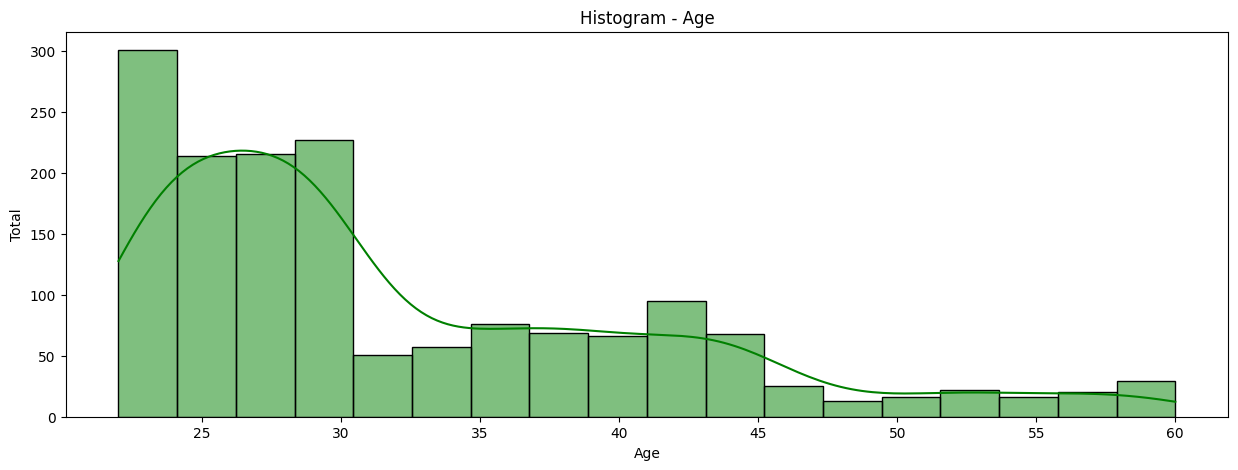

In [0]:
# Exploring Age of target market
plt.figure(figsize=(15,5))
plt.title('Histogram - Age')
plt.xlabel('Age')
plt.ylabel('Total')
sns.histplot(data=df, x='Age', color='green', kde = 'True')
plt.show()

- Majority of car owners are in age group 22 to 30, having strong interest in personal cars
- As age increases after 30, there is steap decline in owning personal cars  

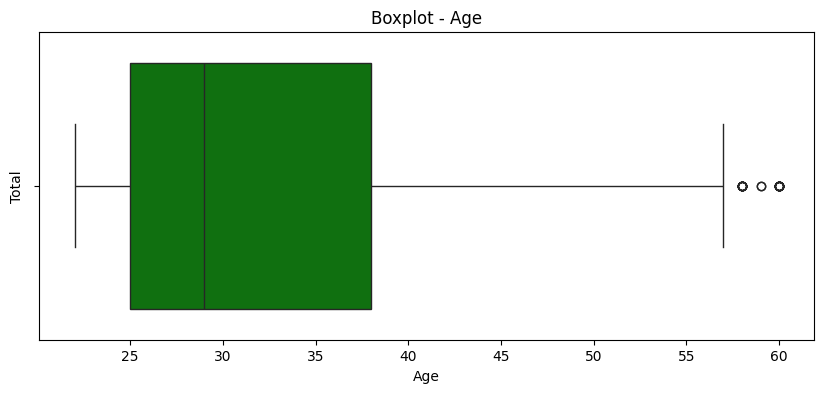

In [0]:
# Exploring Age of target market
plt.figure(figsize=(10,4))
plt.title('Boxplot - Age')
plt.xlabel('Age')
plt.ylabel('Total')
sns.boxplot(data=df, x='Age', color='green')
plt.show()

- Age is right skewed, with median age of 29 years
- Few customers aged above 57 are outliers

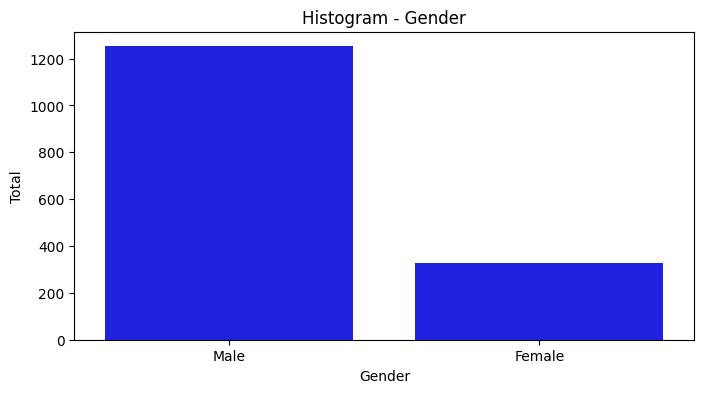

In [0]:
# Exploring Gender of target market
plt.figure(figsize=(8,4))
plt.title('Histogram - Gender')
plt.xlabel('Gender')
plt.ylabel('Total')
sns.countplot(data=df, x='Gender', color='blue')
plt.show()

- More than 1200 cars are owned by males, compared to females with only ~350 cars

In [0]:
# Exploring Gender Perecentage of target market
df['Gender'].value_counts(normalize=True) * 100 

Male      79.190386
Female    20.809614
Name: Gender, dtype: float64

- 80% car owners are male, 20% are females

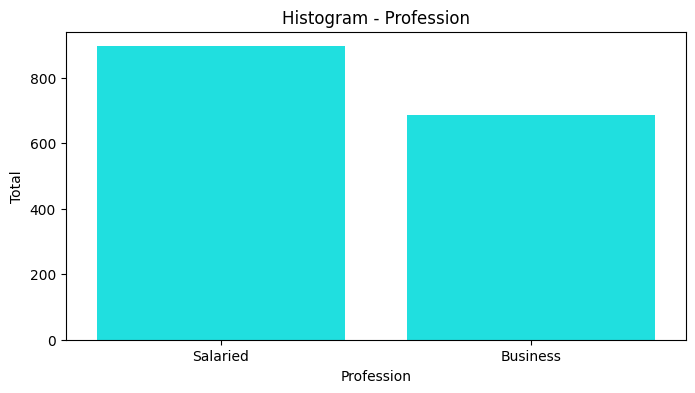

In [0]:
# Exploring Profession of target market
plt.figure(figsize=(8,4))
plt.title('Histogram - Profession')
plt.xlabel('Profession')
plt.ylabel('Total')
sns.countplot(data=df, x='Profession', color='cyan')
plt.show()

- Salaried people owns more cars than Business people

In [0]:
# Exploring Profession Perecentage of target market
df['Profession'].value_counts(normalize=True) * 100 

Salaried    56.672992
Business    43.327008
Name: Profession, dtype: float64

- 56% salaried people owns the car over 43% business people

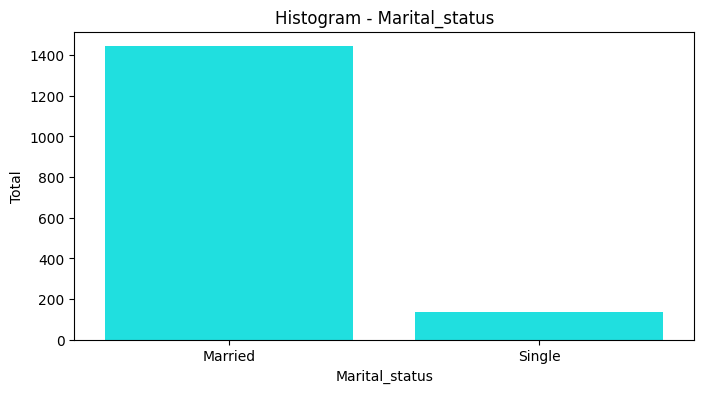

In [0]:
# Exploring Profession of target market
plt.figure(figsize=(8,4))
plt.title('Histogram - Marital_status')
plt.xlabel('Marital_status')
plt.ylabel('Total')
sns.countplot(data=df, x='Marital_status', color='cyan')
plt.show()

- Family plays crucial role in ownership of cars. There is a strong interest of cars in married customers

In [0]:
# Exploring Profession Perecentage of target market
df['Marital_status'].value_counts(normalize=True) * 100 

Married    91.271347
Single      8.728653
Name: Marital_status, dtype: float64

- 91% married customers owns the car, only 8% non-married customers have cars

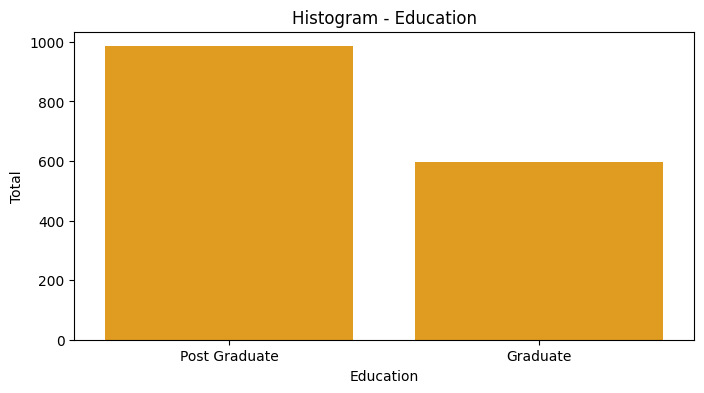

In [0]:
# Exploring Education of target market
plt.figure(figsize=(8,4))
plt.title('Histogram - Education')
plt.xlabel('Education')
plt.ylabel('Total')
sns.countplot(data=df, x='Education', color='orange')
plt.show()

- Education of customers influence owning cars. Higher the education, more changes of need to have personal car

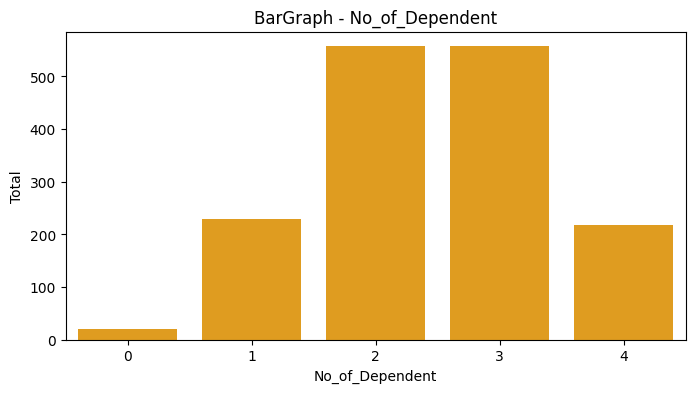

In [0]:
# Exploring No_of_Dependent of target market

plt.figure(figsize=(8,4))
plt.title('BarGraph - No_of_Dependent')
plt.xlabel('No_of_Dependent')
plt.ylabel('Total')
sns.countplot(data=df, x='No_of_Dependents', color='orange')
plt.show()

- Having 1 to 3 dependents, increases chances of owning cars

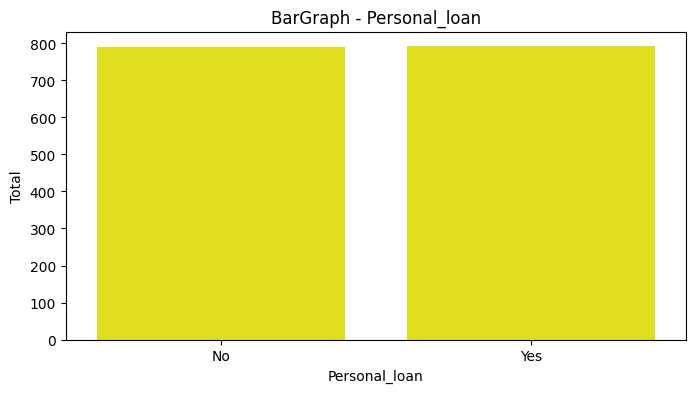

In [0]:
# Exploring Personal_loan of target market

plt.figure(figsize=(8,4))
plt.title('BarGraph - Personal_loan')
plt.xlabel('Personal_loan')
plt.ylabel('Total')
sns.countplot(data=df, x='Personal_loan', color='yellow')
plt.show()

- Personal loan does not influence having the cars directly

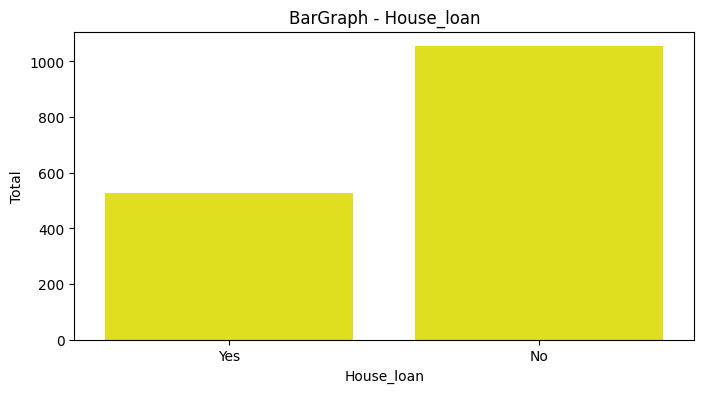

In [0]:
# Exploring House_loan of target market

plt.figure(figsize=(8,4))
plt.title('BarGraph - House_loan')
plt.xlabel('House_loan')
plt.ylabel('Total')
sns.countplot(data=df, x='House_loan', color='yellow')
plt.show()

In [0]:
# Exploring House_loan percentage of target market
df['House_loan'].value_counts(normalize=True) * 100 

No     66.666667
Yes    33.333333
Name: House_loan, dtype: float64

- Customers with no House loan have 50% more chances of owning the car

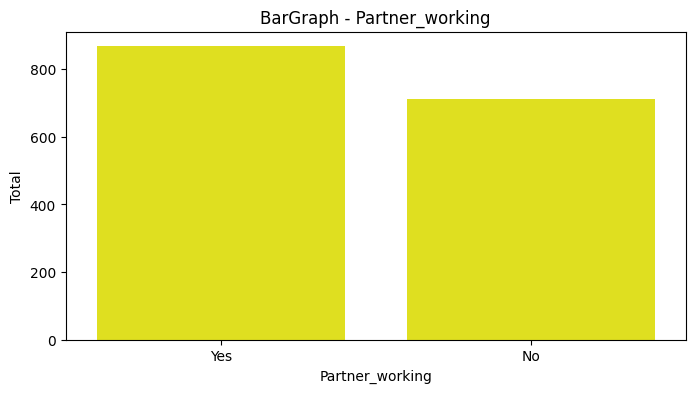

In [0]:
# Exploring Partner_working of target market

plt.figure(figsize=(8,4))
plt.title('BarGraph - Partner_working')
plt.xlabel('Partner_working')
plt.ylabel('Total')
sns.countplot(data=df, x='Partner_working', color='yellow')
plt.show()

- Working partner creates more chances of owning car

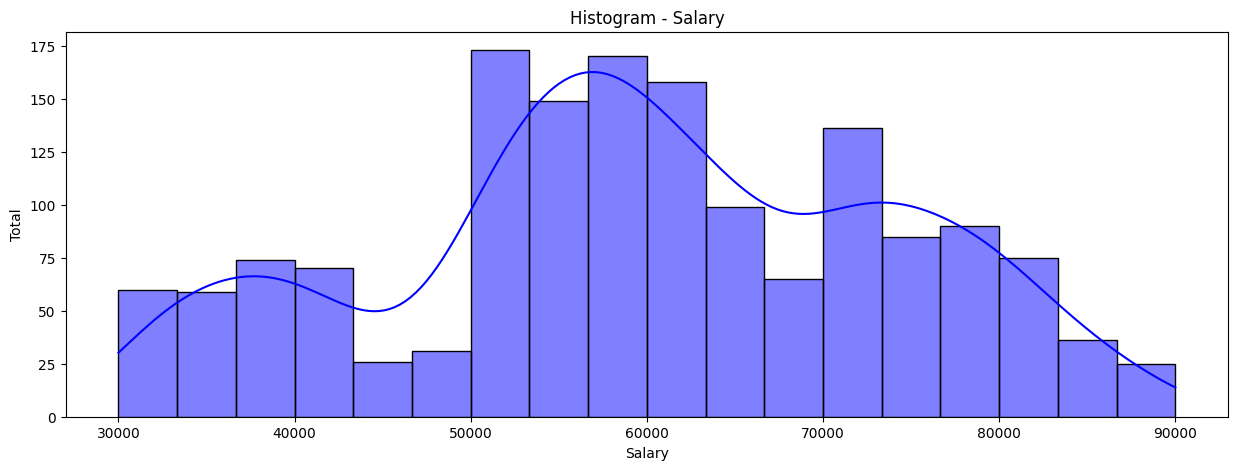

In [0]:
# Exploring Salary of target market

plt.figure(figsize=(15,5))
plt.title('Histogram - Salary')
plt.xlabel('Salary')
plt.ylabel('Total')
sns.histplot(data=df, x='Salary', color='blue', kde='True')
plt.show()

- Some cutsomers earns significantly more than others
- Most commom salary band is around 50000 to 60000 dollars

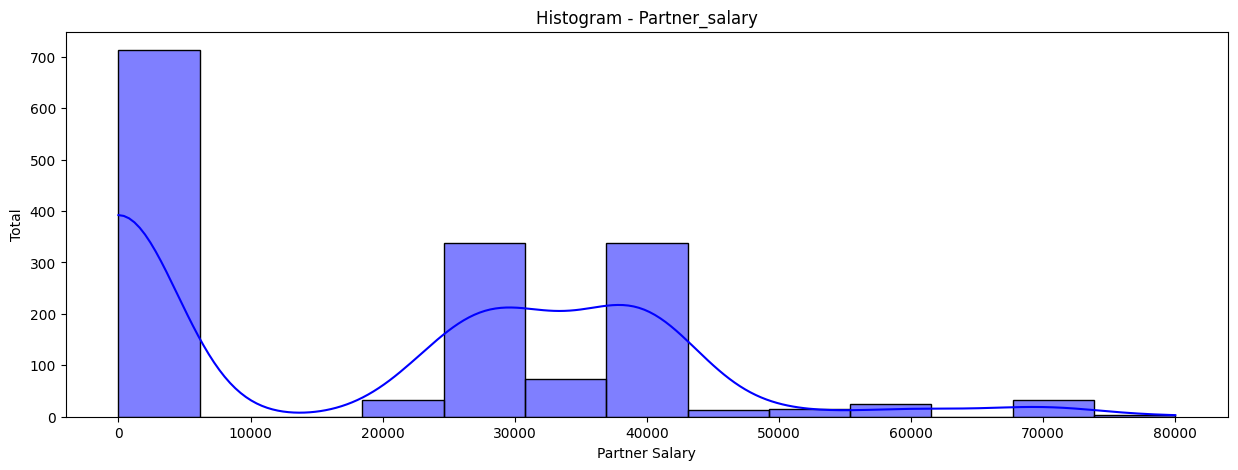

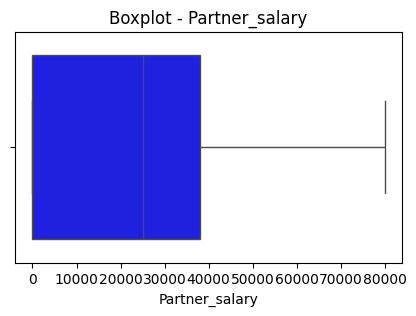

In [0]:
# Exploring Partner_salary of target market

plt.figure(figsize=(15,5))
plt.title('Histogram - Partner_salary')
plt.xlabel('Partner Salary')
plt.ylabel('Total')
sns.histplot(data=df, x='Partner_salary', color='blue', kde='True')
plt.show()

plt.figure(figsize=(5,3))
plt.title('Boxplot - Partner_salary')
sns.boxplot(data=df, x='Partner_salary', color='blue');
plt.show()

- Partner_salary data is highly right skewed, indicating strong concentration near 0$ salary and very rare cases of high earners
- Many customers have non-working partners, as most of the partners have 0$ salary or income not declared
- Partner_Salary has 2 groups of income holders
  - One with 25000 to 30000
  - second with 35000 to 45000
- There are no outliers in data


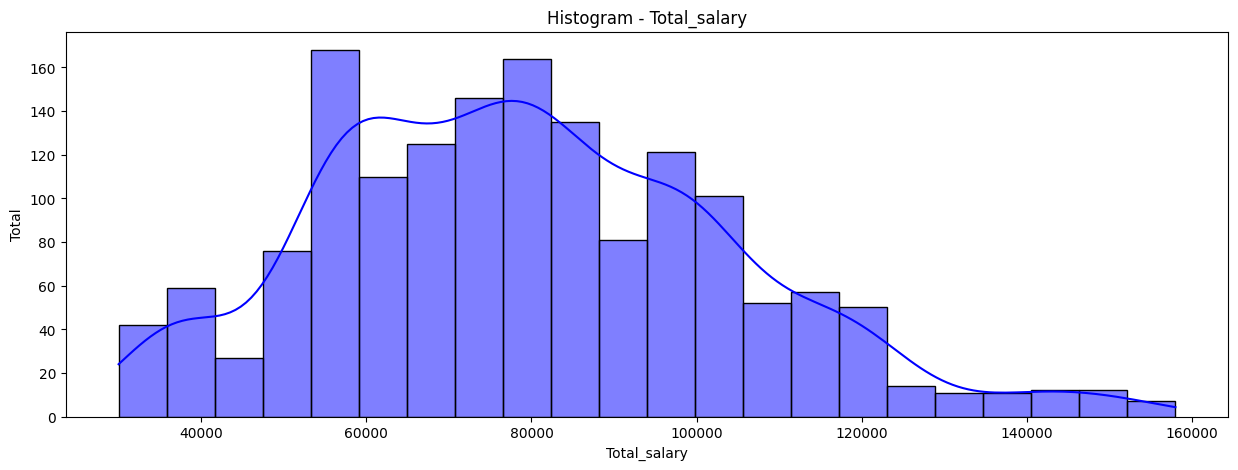

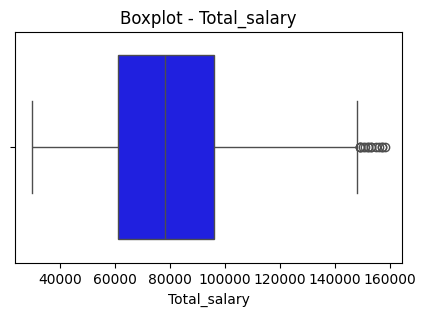

In [0]:
# Exploring Total_salary of target market

plt.figure(figsize=(15,5))
plt.title('Histogram - Total_salary')
plt.xlabel('Total_salary')
plt.ylabel('Total')
sns.histplot(data=df, x='Total_salary', color='blue', kde='True')
plt.show()

plt.figure(figsize=(5,3))
plt.title('Boxplot - Total_salary')
sns.boxplot(data=df, x='Total_salary', color='blue');
plt.show()

- Total_salary data is right skewed
- Many outliers detected with salary more than 160,000 dollars indicating very high income customers
- Most of the customers holds income ranges between 60,000 to 95,000


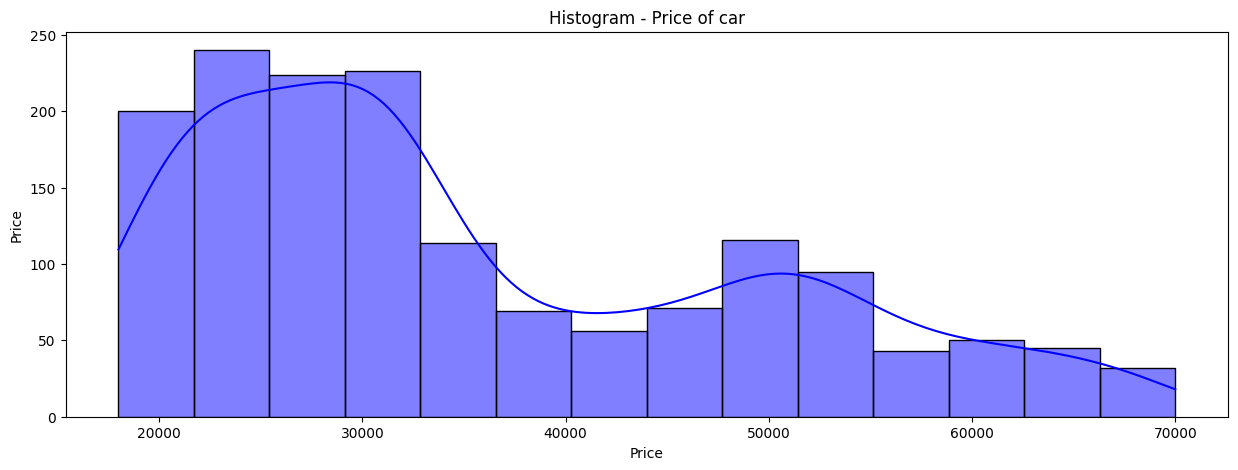

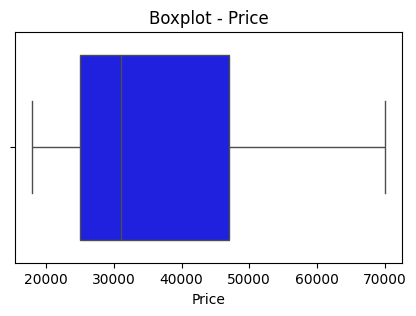

In [0]:
# Exploring Price of target market

plt.figure(figsize=(15,5))
plt.title('Histogram - Price of car')
plt.xlabel('Price')
plt.ylabel('Price')
sns.histplot(data=df, x='Price', color='blue', kde='True')
plt.show()

plt.figure(figsize=(5,3))
plt.title('Boxplot - Price')
sns.boxplot(data=df, x='Price', color='blue')
plt.show()

- Price of car data is again right skewed. No outliers in Price of cars
  - Most of the cars with range 25000 to 45000, reflecting demand for affordability and mid-range vehicle
  - Permium and luxury cars are less common due to high price

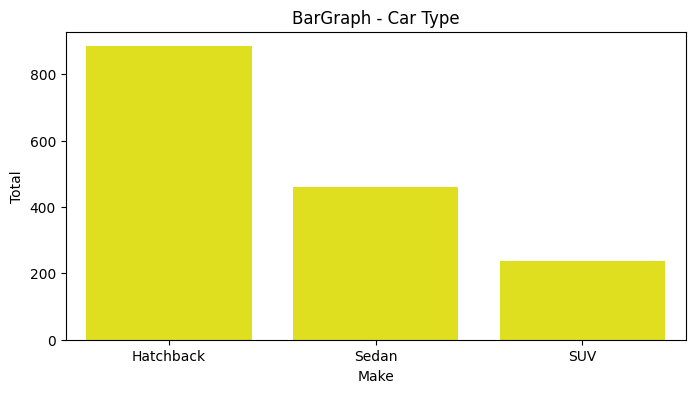

In [0]:
# Exploring Make of target market

plt.figure(figsize=(8,4))
plt.title('BarGraph - Car Type')
plt.xlabel('Make')
plt.ylabel('Total')
sns.countplot(data=df, x='Make', color='yellow', order=df['Make'].value_counts().index)
plt.show()

- Hatchback cars are most popular choice (around 850 customers), followed by Sedan (~450 customers) and SUV being least prefered (only ~250 customers)

#### Observations:

**Summary of univariate analysis**
- Strong Preference of personal cars among youngsters aged 22 to 30 years
- Gender plays crucial role in interest in cars with male being dominating group for car ownership
- Customers who are married, have very high chances of owning personal car
  - Most of the customers have non-working partners
  - Working partner increases the chances of buying a car
  - Customers with more dependent have more chances of buying a car
- Highly educated people have more demand for cars
- House loan decreases the chances of having cars by 50%, Personal loan does not impact sales of car
- Customers earning mid-range between 50K to 60K have strong desire for car
  - Working partner have little influence in car ownership as most of the partners are non-working or with no declaration of salary
- Affordable cars with price ranges between 25000 to 45000 are highly demanding, premium cars are owned by less people
- Most comman car is hatchback, followed by Sedan and SUV is least preferred choice


In [0]:
df.loc[(df['Price'] > 25000) & (df['Make'] == 'Hatchback'), 'Make'].value_counts()

Hatchback    444
Name: Make, dtype: int64

In [0]:
df2 = df[(df['Make'] == 'Hatchback') & (df['Price'] > 25000)]
df2.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,444.0,25.914414,2.531404,22.0,24.0,26.0,28.0,30.0
No_of_Dependents,444.0,3.024775,0.842879,1.0,2.0,3.0,4.0,4.0
Salary,444.0,55380.630631,12736.669074,30000.0,49750.0,56000.0,65000.0,80000.0
Partner_salary,444.0,18461.711712,16391.950696,0.0,0.0,28000.0,32000.0,50000.0
Total_salary,444.0,73842.342342,20075.869862,30000.0,59000.0,74000.0,89250.0,120000.0
Price,444.0,29398.648649,2173.324418,26000.0,28000.0,29000.0,31000.0,33000.0


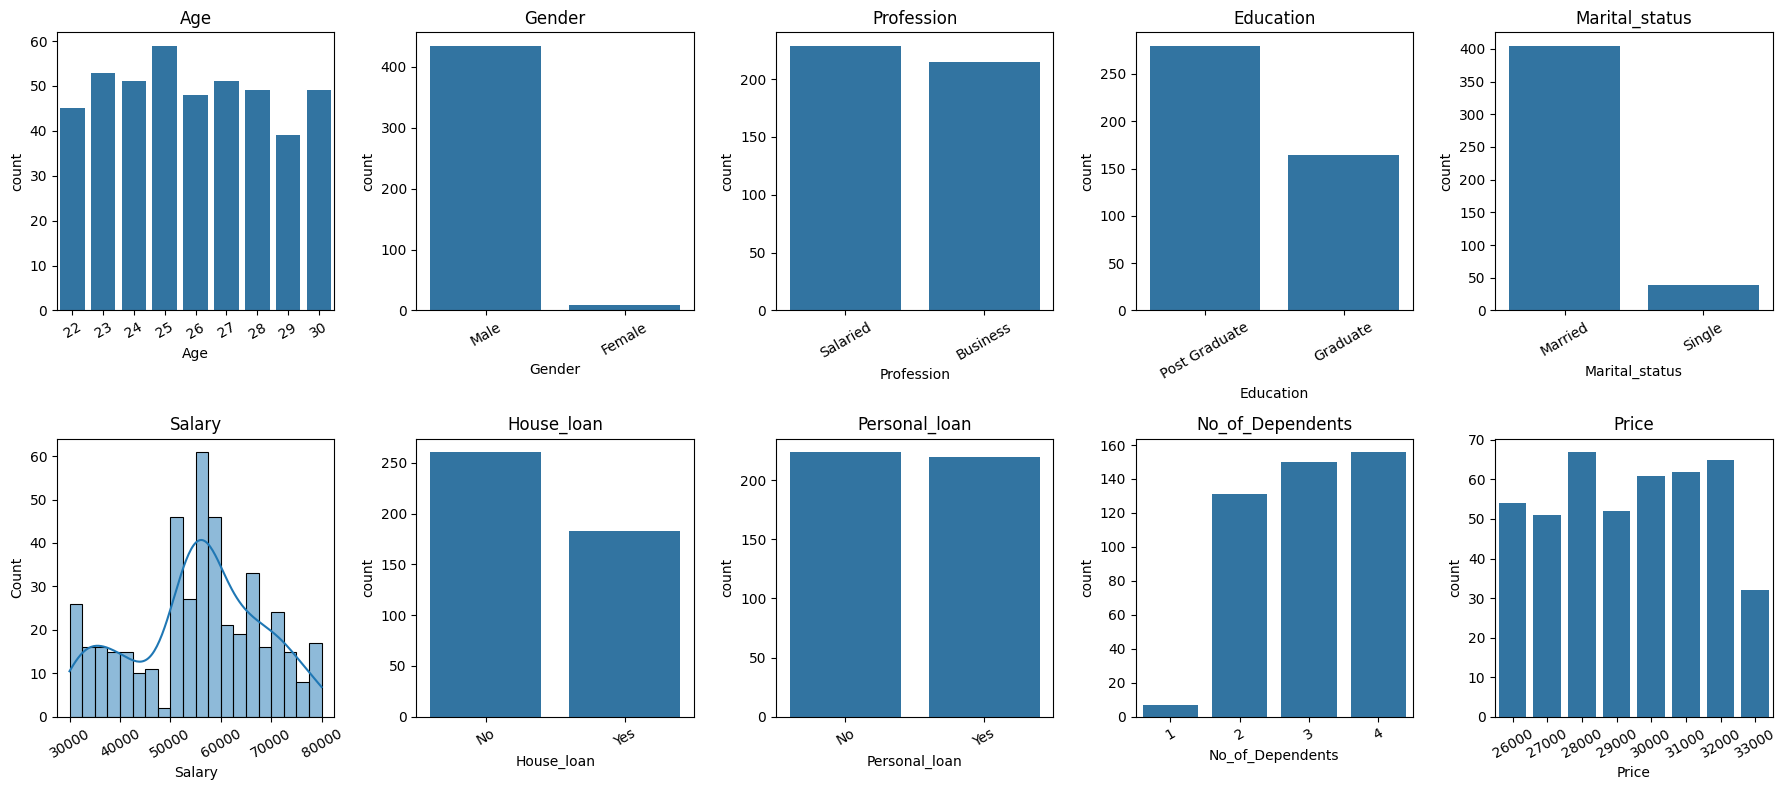

In [0]:
cols = ['Age', 'Gender', 'Profession', 'Education', 'Marital_status', 'Salary', 'House_loan', 'Personal_loan', 'No_of_Dependents', 'Price']

# Grid setup
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(18, 8))
axes = axes.flatten()

# Loop through and plot
for i, col in enumerate(cols):
    ax = axes[i]
    if df2[col].dtype == 'object' or df2[col].nunique() < 10:
        sns.countplot(x=col, data=df2, ax=ax)
    else:
        sns.histplot(df2[col], bins=20, kde=True, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)

# Hide extra axes if any
for j in range(len(cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### Observations:

**Cars with Type Hashback and Price more than 25000**
- Age of the customers is between 22 to 30, indicating 
- Males are the main target group of potential buyers
- Married male have strong chances to buy cars
- More dependents (usually 2 to 4) influence more potential buyers
- House loan decreases the chances of owming the cars
- Salary of customers are in range 50,000 to 60,000

In [0]:
df3 = df[df['Price'] > df['Salary']]

print('Total owners who bought cars that were priced higher than their salary', df3.shape[0])

print('Customer who have taken personal loans', df3['Personal_loan'].value_counts()['Yes'])


Total owners who bought cars that were priced higher than their salary 96
Customer who have taken personal loans 44


In [0]:
# How much percentage of customers have car cost higher than their salary
( df3.shape[0] / df.shape[0] ) * 100

6.072106261859583

In [0]:
# Calculating percentage of personal loans taken
df3['Personal_loan'].value_counts(normalize=True) * 100

No     54.166667
Yes    45.833333
Name: Personal_loan, dtype: float64

#### Observations:

- Only 96 customers (6%) have cars priced higher than their salary
- Only 44 customers out of 96 have personal loans



### Multivariate Analysis

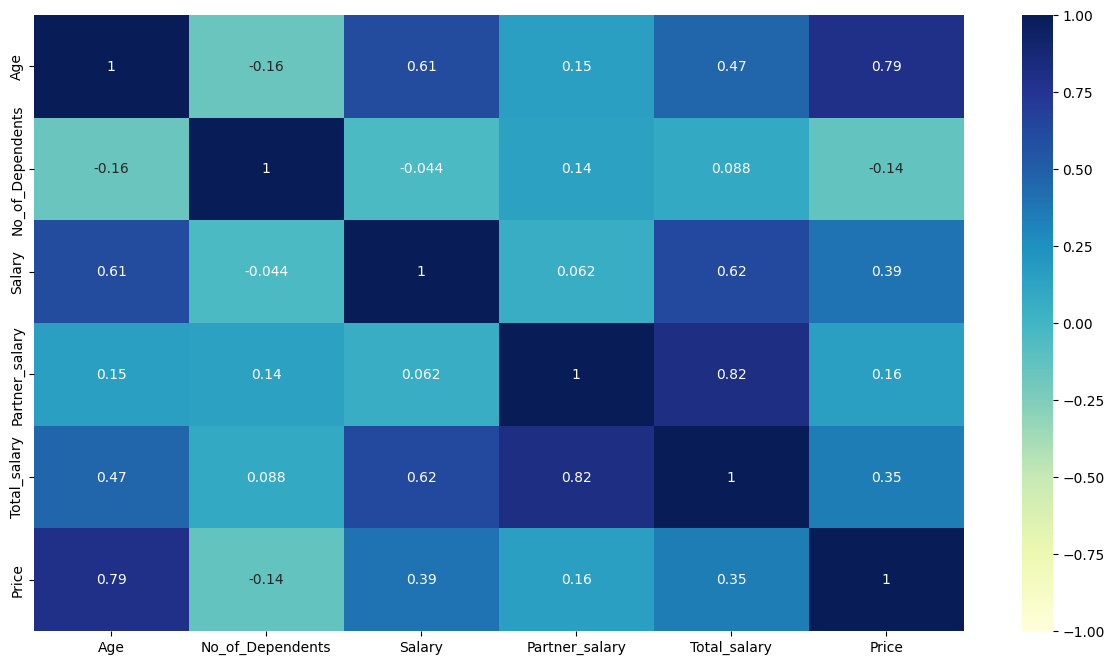

In [0]:
# Find correlation between all the columns which are continuous
plt.figure(figsize=(15,8))
sns.heatmap(data = df[df.columns].corr(), annot=True, cmap='YlGnBu', vmin=-1, vmax=1)
plt.show()

- Older customers tend to buy more expensive cars
- Both individual and household income only moderately influence car price decisions
- Household income is heavily influenced by partner's earnings
- Older customers often contribute to higher household income, possibly due to experience or addition of partner income
- Number of dependents doesn’t significantly affect salary or car buying decision in this data

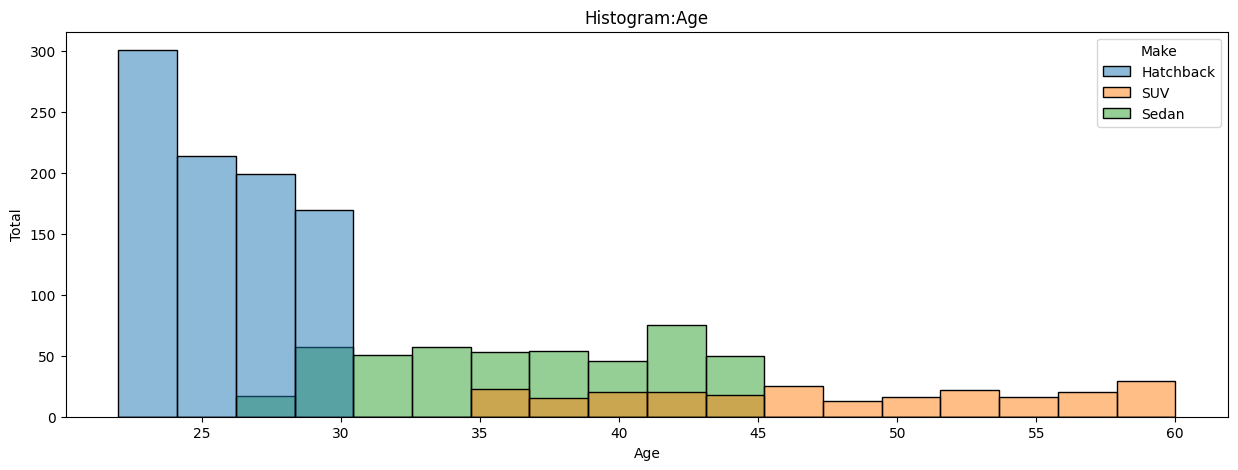

In [0]:
# Exploring Age of target market
plt.figure(figsize=(15,5))
plt.title('Histogram:Age')
plt.xlabel('Age')
plt.ylabel('Total')
sns.histplot(data=df, x='Age', color='orange', hue='Make')
plt.show()

- Impact of Age wrt personal cars:
  - We observe that Customer's aged below 30 have more interest in personal cars
  - Hatchback is the popular choice amongst yongsters aged below 30
  - Customers aged between 30 to 45 have comparitively low craze for cars with preference of Sedan, SUV's prefered by customer aged between 45 to 60
- Age is a key driver for Personal cars and choice of cars

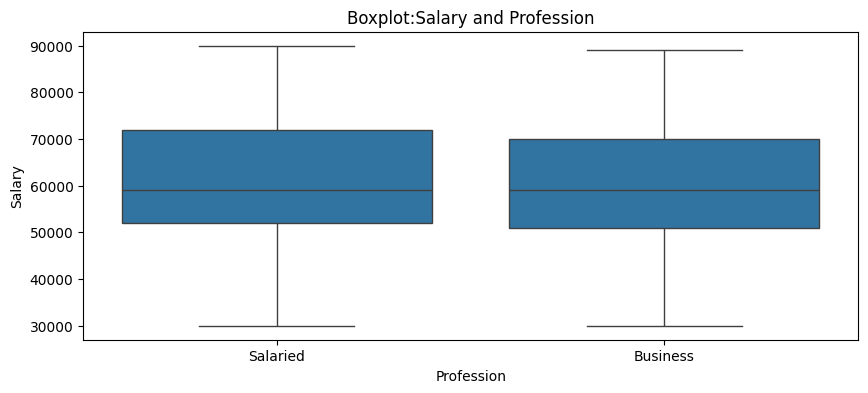

In [0]:
plt.figure(figsize=(10,4))
plt.title('Boxplot:Salary and Profession')
plt.xlabel('Profession')
plt.ylabel('Salary')
sns.boxplot(x='Profession', y='Salary', data=df);

- No outlier detected
- Salaried people have little edge over business class to own car. There is not much difference across profession though

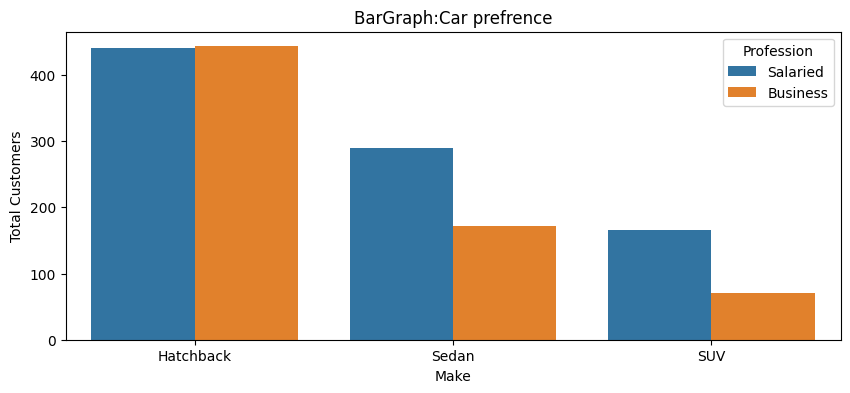

In [0]:
plt.figure(figsize=(10,4))
plt.title('BarGraph:Car prefrence')
plt.xlabel('Make')
plt.ylabel('Total Customers');
sns.countplot(x='Make', hue='Profession', data=df, order=['Hatchback', 'Sedan', 'SUV']);

- In every car model type, salaried customers owns more cars than Business person 

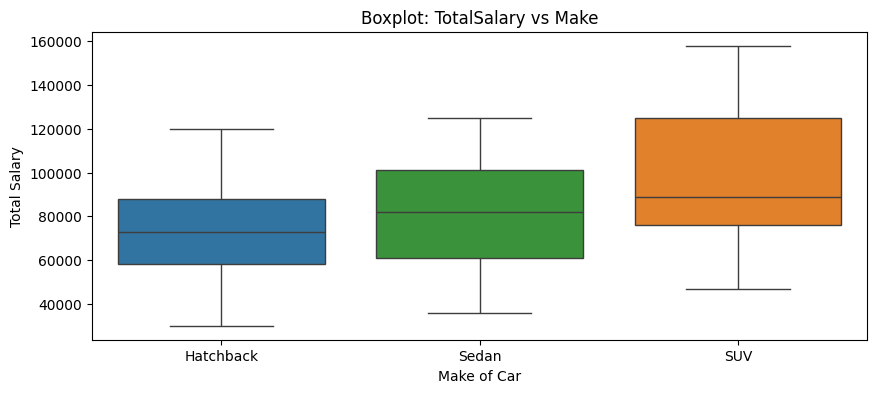

In [0]:
plt.figure(figsize=(10,4))
plt.title('Boxplot: TotalSalary vs Make')
plt.xlabel('Make of Car')
plt.ylabel('Total Salary')
sns.boxplot(x='Make', y='Total_salary', data=df, hue='Make', order=['Hatchback', 'Sedan', 'SUV']);

- Mean of SUV is higher than Sedan and Hatchback and the IQR width is also widder.
  - Higher the Family income, drives higher chances of owning luxury cars
  - Hashback is most affordable choice for low income households

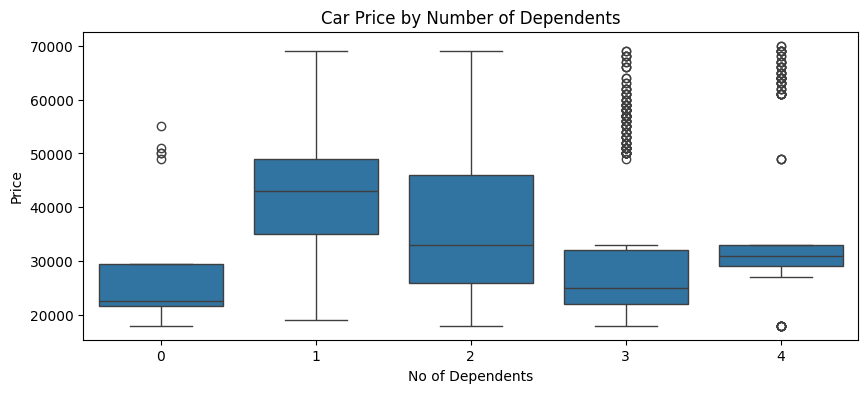

In [0]:
plt.figure(figsize=(10,4))
plt.title('Car Price by Number of Dependents')
plt.xlabel('No of Dependents')
plt.ylabel('Price');
sns.boxplot(x='No_of_Dependents', y='Price', data=df);

- Mean of Price based on No_Of_Dependents is higher in case no of depedents are 1 or 2
  - Wider IQR, they buy both entry and premium models
  - Fewer dependents may mean early career individuals with budget constraints
  - Even people with 0 or 4 dependents sometimes buy high-end cars (50k+), but they are exceptions

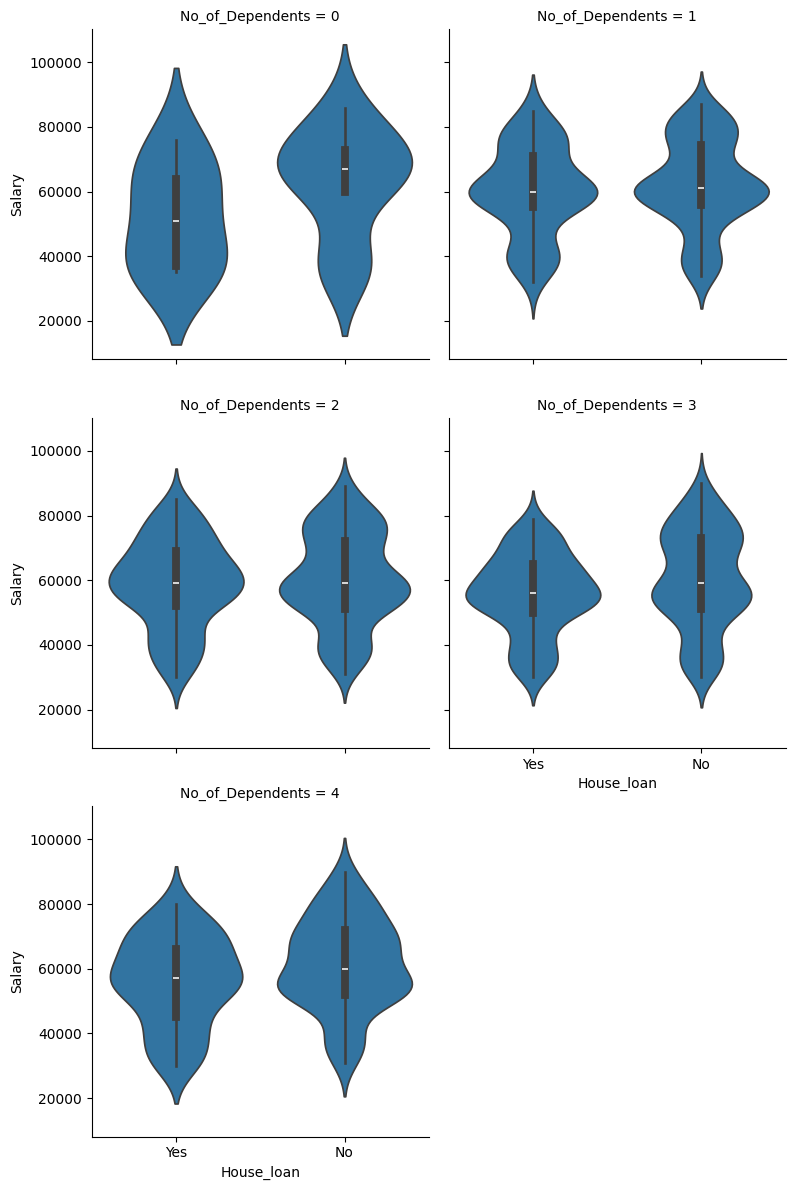

In [0]:
# ViolinPlot: House_loan and Salary distribution wrt no_of_dependents in family
sns.catplot(x='House_loan', y='Salary', col='No_of_Dependents',
            data=df, col_wrap=2, kind='violin',
            height=4, aspect=1);

- Salary distribution remains stable across both loan status and number of dependents, so these features may not independently drive income level or loan decisions that much

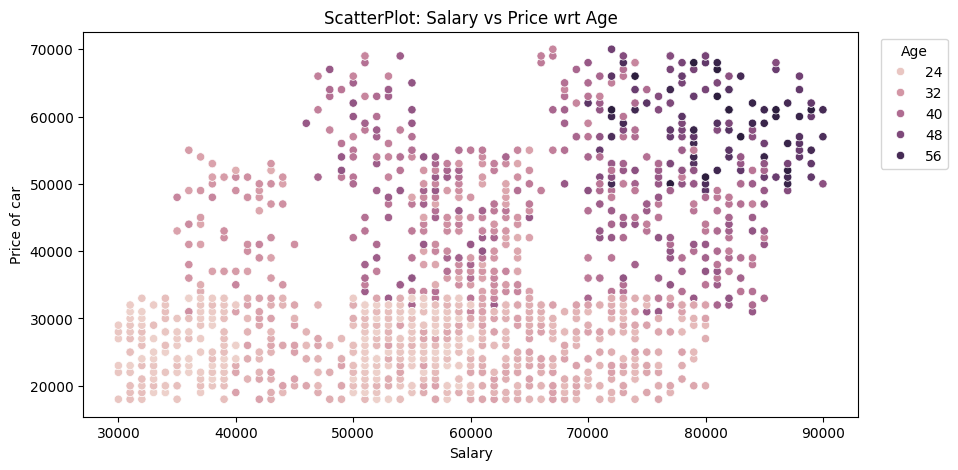

In [0]:
plt.figure(figsize=(10,5))
plt.title('ScatterPlot: Salary vs Price wrt Age')
plt.xlabel('Salary')
plt.ylabel('Price of car')
sns.scatterplot(x='Salary', y='Price', data=df, hue='Age');
plt.legend(title='Age', bbox_to_anchor=(1.02, 1));

- Higher the age, higher the chnaces of owning luxury car
- More experienced the customer, more chances of having higher salary and luxury car

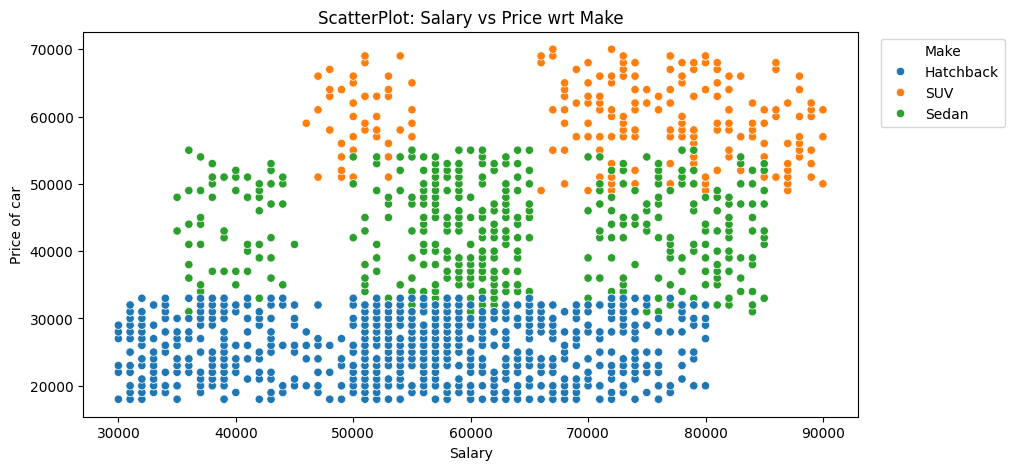

In [0]:
plt.figure(figsize=(10,5))
plt.title('ScatterPlot: Salary vs Price wrt Make')
plt.xlabel('Salary')
plt.ylabel('Price of car')
sns.scatterplot(x='Salary', y='Price', data=df, hue='Make');
plt.legend(title='Make', bbox_to_anchor=(1.02, 1));

- Hatchback is affordable and preferred choice irrepective of salary
- SUV's are premimum and expensive choice with target consumer belonging to higher income class
- Sedan is again a 2nd popular choice with all salary class people with a higher price range

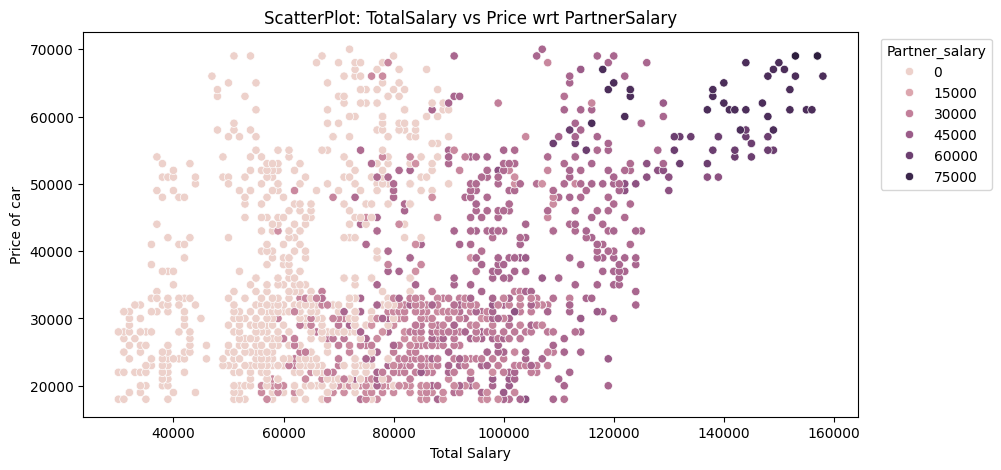

In [0]:
plt.figure(figsize=(10,5))
plt.title('ScatterPlot: TotalSalary vs Price wrt PartnerSalary')
plt.xlabel('Total Salary')
plt.ylabel('Price of car')
sns.scatterplot(x='Total_salary', y='Price', data=df, hue='Partner_salary');
plt.legend(title='Partner_salary', bbox_to_anchor=(1.02, 1));

- Partner_Salary influences the total salary of household and more chances of owning luxury cars

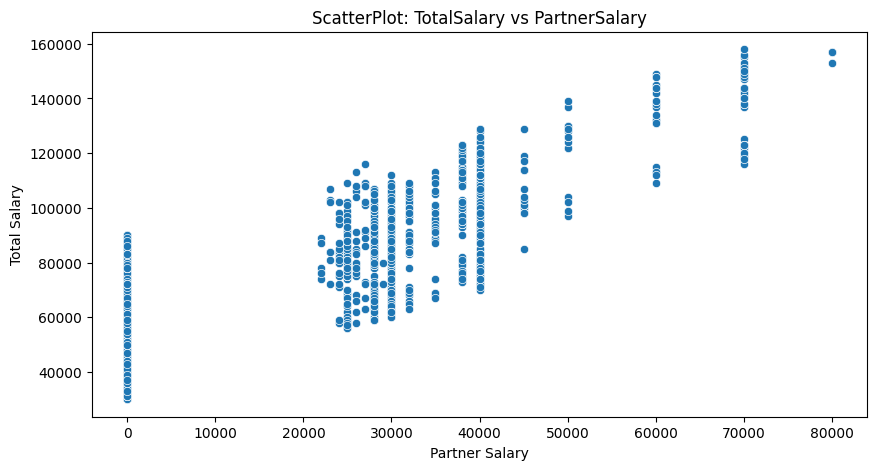

In [0]:
plt.figure(figsize=(10,5))
plt.title('ScatterPlot: TotalSalary vs PartnerSalary')
plt.ylabel('Total Salary')
plt.xlabel('Partner Salary')
sns.scatterplot( x='Partner_salary', y='Total_salary', data=df);

- As partner salary increases, total salary increases indicating high income household and probably higher chances of affording car

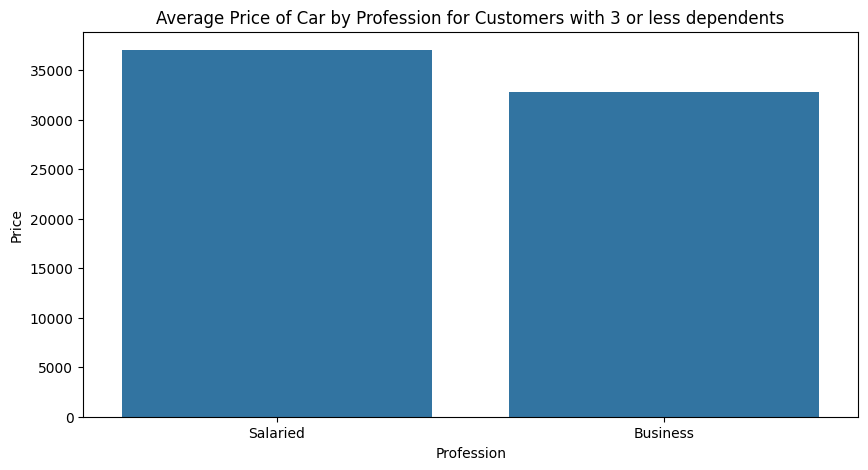

In [0]:
filtered_df = df[df['No_of_Dependents'] <= 3]
avg_price_df = filtered_df.groupby('Profession')['Price'].mean().reset_index()

plt.figure(figsize=(10,5))
plt.title('Average Price of Car by Profession for Customers with 3 or less dependents')
sns.barplot(x='Profession', y='Price', data=avg_price_df, order=['Salaried', 'Business']);

#### Observations:

- Salaried customers spend more on average than business customers when they have 3 or fewer dependents


<Axes: title={'center': 'Price of Car by Profession for Customers with Home loan and personal loan'}, xlabel='Profession', ylabel='Price'>

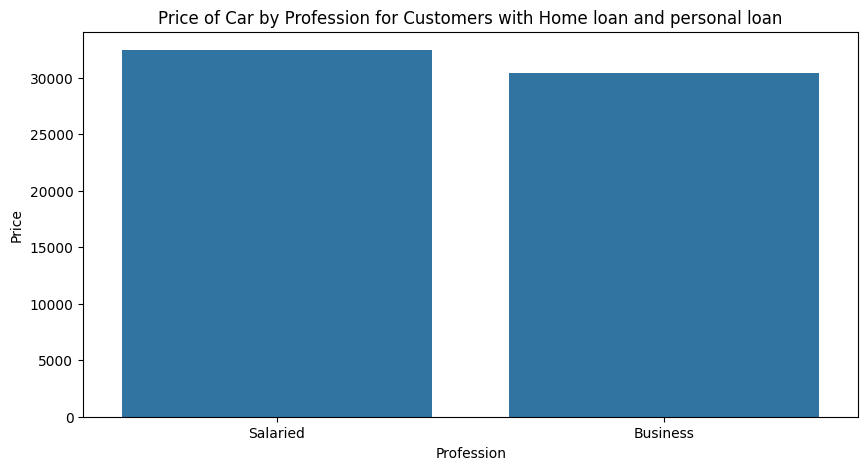

In [0]:
filtered_df2 = df [ (df['House_loan'] == 'Yes') & (df['Personal_loan'] == 'Yes') ]
avg_price_df2 = filtered_df2.groupby('Profession')['Price'].mean().reset_index()

plt.figure(figsize=(10,5))
plt.title('Price of Car by Profession for Customers with Home loan and personal loan')
sns.barplot(x='Profession', y = 'Price', data=avg_price_df2, order=['Salaried', 'Business'])

#### Observations:

- Salaried professionals spend more, as they have cars priced higher than Business professionals on average


## Conclusion and Recommendations


**Conclusion**
- The majority of car buyers are young (22–30 years old), married, and predominantly male
- Hatchbacks are the most preferred car type, followed by Sedans and then SUVs
- Customers with 1 to 3 dependents are more likely to purchase higher-priced cars
- Salaried professionals own more cars and spend more on average compared to business owners, same for more educated people the chances of owning car is high
- Partner income is often zero, but when present, it contributes to higher total income and increases the chance of owning higher-priced vehicles like SUVs
- House loans slightly reduce the likelihood of car ownership; personal loans have almost no effect
- Cars are most commonly priced between ₹25,000 to ₹45,000, indicating strong demand for mid-range, affordable vehicles

**Business Recommendation**
- Austo should target young, salaried, married customers with 1 to 3 dependents, as they represent the most active car-buying segment
- The company should prioritize production and promotion of hatchbacks and mid-range sedans to meet current demand trends
- Car models should be priced and financed to fall within the ₹25,000–₹45,000 range to maximize sales conversion in the mass market
- Marketing efforts should be segmented based on household income and education levels, focusing on aspirational value for postgraduate, mid-income families
- Austo should not heavily rely on personal loan tie-ins, but rather offer flexible pricing and bundled offers that appeal regardless of loan status

___